In [1]:
%load_ext autoreload
%autoreload 2

from functions.data_manager import *
from functions.derivative_method import *
from functions.metrics import *
from functions.reconstruction import *

import pandas as pd
from IPython.display import display

The whole dataset is loaded and because of its nested structure, it is flattened. In this notebook, we will only analyse the "Active" neurons.

In [2]:
data_dict = load_selected_data(num_datasets='all', num_neurons_per_dataset='all')
flat_data = flatten_datasets(data_dict)

In [8]:
# Create the subgroup
data_inactive_neurons = [d for d in flat_data if 0 < len(d['spikes']) < 100]

# Quick check to see how many made the cut
print(f"Total flat_data: {len(flat_data)}")
print(f"flat_data with > 100 spikes: {len(data_inactive_neurons)}")

Total flat_data: 1157
flat_data with > 100 spikes: 576


As recorded data is not evenly distributed in time axis, we need to resample it.

In [9]:
# Define new sampling rate (e.g., 30Hz or 100Hz)
new_rate = 100 

upsampled_results = []

for neuron in data_inactive_neurons:
    # key lookup depends on your dictionary structure, assuming 'times', 'dff', 'spikes'
    times = neuron['t']
    dff = neuron['dff']
    spikes = neuron['spikes']
    
    # helper function usage
    upsampled_signal, upsampled_spikes, evenly_spaced_time = upsample_v2(
        times=times, 
        dff=dff, 
        spikes=spikes, 
        new_rate=new_rate, 
        do_plot=False
    )
    
    upsampled_results.append({
        'original_neuron': neuron, # Keep reference if needed
        'upsampled_signal': upsampled_signal,
        'upsampled_spikes': upsampled_spikes,
        'evenly_spaced_time': evenly_spaced_time
    })

# If you specifically need just a simple list of the signals array:
list_of_upsampled_signals = [res['upsampled_signal'] for res in upsampled_results]

print(f"Upsampled {len(upsampled_results)} neurons.")

Upsampled 576 neurons.


Here you can check the resampled signals superimposed on the original signals.

In [10]:
def plot_neuron_comparison(index, original_data_list, upsampled_data_list):
    """
    Plots the original vs upsampled signal and spikes for a given neuron index.
    
    Args:
        index (int): Index of the neuron to plot.
        original_data_list (list): List of original neuron dictionaries.
        upsampled_data_list (list): List of results from the upsampling step.
    """
    if index >= len(original_data_list) or index >= len(upsampled_data_list):
        print(f"Index {index} is out of bounds.")
        return

    # Extract original data
    orig_neuron = original_data_list[index]
    orig_times = orig_neuron['t']
    orig_dff = orig_neuron['dff']
    orig_spikes = orig_neuron['spikes']

    # Extract upsampled data
    ups_res = upsampled_data_list[index]
    ups_times = ups_res['evenly_spaced_time']
    ups_signal = ups_res['upsampled_signal']
    ups_spikes = ups_res['upsampled_spikes']

    plt.figure(figsize=(15, 6))

    # --- Plot Signals ---
    # Plot original signal as scatter/line to see points clearly
    plt.plot(orig_times, orig_dff, 'o-', color='gray', alpha=0.5, label='Original Signal', markersize=4)
    # Plot upsampled signal as a smooth line
    plt.plot(ups_times, ups_signal, '-', color='tab:blue', label='Upsampled Signal', linewidth=2)

    # --- Plot Spikes ---
    # We use vlines or tick marks to show spikes. 
    # To make them visible, we place them slightly above the max signal or superimpose.
    
    # Calculate a y-position for spikes so they are visible
    max_val = max(np.max(orig_dff), np.max(ups_signal))
    min_val = min(np.min(orig_dff), np.min(ups_signal))
    range_val = max_val - min_val
    
    # Offset spikes slightly
    spike_y_orig = max_val + range_val * 0.05
    spike_y_ups = max_val + range_val * 0.1
    
    # Plot Original Spikes
    plt.plot(orig_spikes, [spike_y_orig] * len(orig_spikes), '|', color='gray', 
             label='Original Spikes', markersize=15, markeredgewidth=2)
    
    # Plot Upsampled Spikes 
    # (Note: They should align closely with original spikes, maybe slightly shifted due to time grid if not exact)
    plt.plot(ups_spikes, [spike_y_ups] * len(ups_spikes), '|', color='tab:red', 
             label='Upsampled Spikes', markersize=15, markeredgewidth=2)

    plt.xlabel('Time (s)')
    plt.ylabel('Signal (DF/F)')
    plt.title(f'Neuron {index}: Original vs Upsampled Signal & Spikes')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.show()

# Example usage:
# Change index to view different neurons

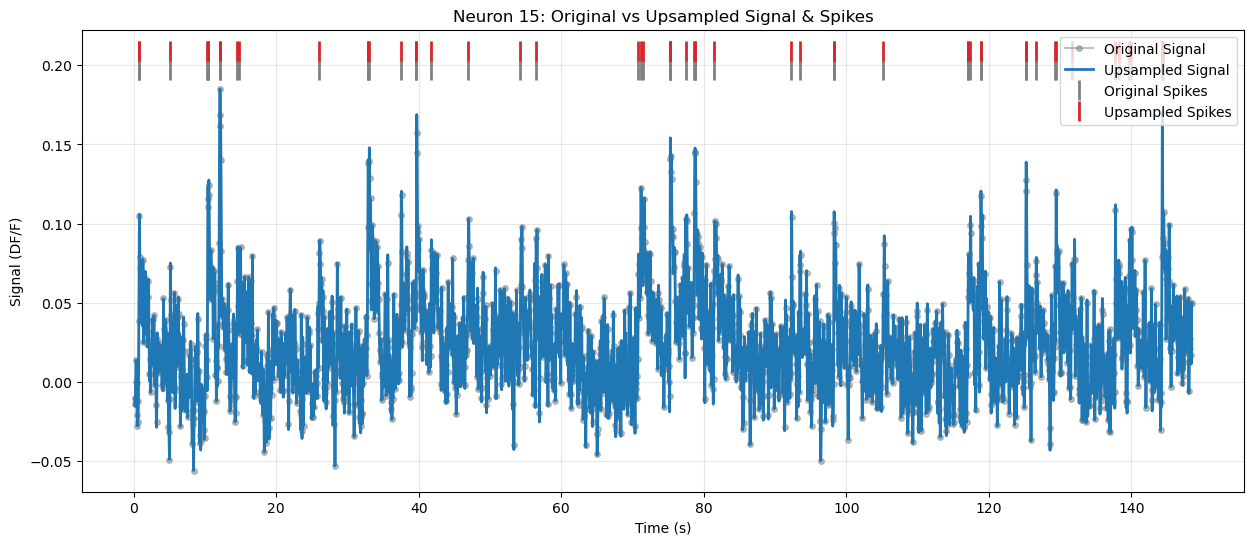

In [12]:
plot_neuron_comparison(15, data_inactive_neurons, upsampled_results)

From now on we make a list "neurons" and store everythingrelated to each neurons n it. it has original_neuron and upsampled part. any new measurement is stored in the upsampled part.

In [13]:
# This will hold the final list of neuron dictionaries with tau added
neurons = []

for item in upsampled_results:
    # 1. Get references to data (using the keys from upsample_v2 results)
    u_sig = item['upsampled_signal']
    u_spk_times = item['upsampled_spikes'] # times in seconds
    u_time = item['evenly_spaced_time']
    
    # 2. Determine sampling rate (fs)
    if len(u_time) > 1:
        fs = 1.0 / (u_time[1] - u_time[0])
    else:
        fs = 30.0 # Default fallback
    
    t_start = u_time[0]

    # 3. Convert spike Times to Indices
    # Formula: index = (time - start_time) * fs
    u_spk_indices = ((u_spk_times - t_start) * fs).astype(int)
    
    # Filter indices to be within bounds
    u_spk_indices = u_spk_indices[(u_spk_indices >= 0) & (u_spk_indices < len(u_sig))]

    # 4. Estimate Tau
    try:
        # window_len=51, poly_order=3, cut_win=10 are standard defaults
        tau_val, fit_data = estimate_tau(u_sig, u_spk_indices, window_len=51, poly_order=3, cut_win=10)
    except Exception as e:
        print(f"Error for neuron: {e}")
        tau_val = np.nan
        fit_data = (None, None)

    # 5. Add new fields to the dictionary
    # We copy the item to avoid modifying the original list in place if that matters, 
    # or just modify 'item' directly. Here we modify 'item' and append to 'neurons'.
    item['tau'] = tau_val
    item['fit_data'] = fit_data
    
    # Add to our final list
    neurons.append(item)

print(f"Processed {len(neurons)} neurons. New fields 'tau' and 'fit_data' added.")

Processed 576 neurons. New fields 'tau' and 'fit_data' added.


In order to have everything available in neurons list, we need a spike trains for each neuron on the evenly sampled time grid. We already have calculated it in upsampled spikes train. But, this is a binary vector, not a series of event times.

In [14]:
# Assuming 'neurons' list has been populated
for neuron in neurons:
    # 1. Get required data
    u_spk = neuron['upsampled_spikes']      # Spike times in seconds
    u_time = neuron['evenly_spaced_time']   # Time grid
    
    # 2. Generate binary spike train
    spikes_train = get_spikes_train(u_spk, u_time)
    
    # 3. Add to neuron dictionary
    neuron['spikes_train'] = spikes_train

print(f"Added 'spikes_train' to {len(neurons)} neurons.")

Added 'spikes_train' to 576 neurons.


In [15]:
# Loop through neurons and add reconstructed spikes
for n in neurons:
    # 1. Get upsampled signal and tau
    u_sig = n['upsampled_signal']
    tau = n['tau']
    
    # 2. Check if tau is valid before reconstruction
    if not np.isnan(tau) and tau > 0:
        # Reconstruct spikes (returns 1D array since input is 1D)
        rec_spikes = reconstruct_spikes(u_sig, tau=tau)
        n['reconstructed_spikes'] = rec_spikes
    else:
        n['reconstructed_spikes'] = np.zeros_like(u_sig) # Or None

print("Added 'reconstructed_spikes' to neurons.")

Added 'reconstructed_spikes' to neurons.


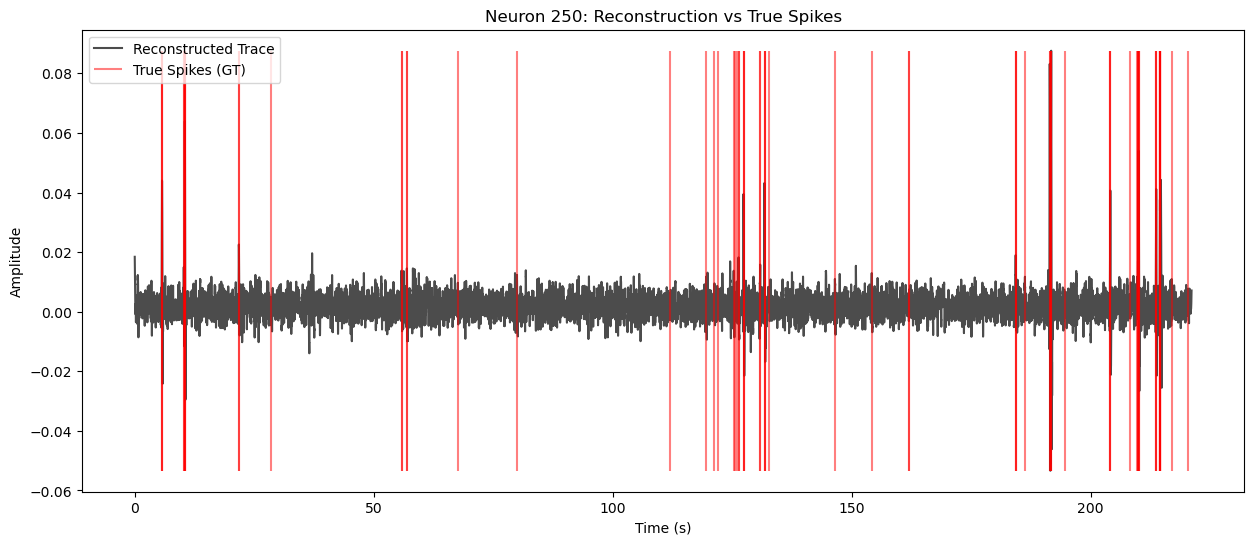

In [17]:
# 1. Select a neuron by index (e.g., 10)
neuron_idx = 250
n = neurons[neuron_idx] # Accessing the dictionary for this neuron

# 2. Extract Data
# The continuous reconstruction is already stored in the list
rec_trace = n['reconstructed_spikes'] 
time_axis = n['evenly_spaced_time']     
true_spikes = n['original_neuron']['spikes'] # True spikes in SECONDS

# 3. Plot Comparison
plt.figure(figsize=(15, 6))

# Plot Reconstructed Spike Trace (Continuous)
plt.plot(time_axis, rec_trace, color='black', alpha=0.7, label='Reconstructed Trace')

# Plot True Spikes (Discrete Events)
# Use vertical lines at the exact timestamps
plt.vlines(true_spikes, 
           ymin=np.min(rec_trace), 
           ymax=np.max(rec_trace), 
           colors='red', 
           alpha=0.5, 
           label='True Spikes (GT)')

plt.title(f'Neuron {neuron_idx}: Reconstruction vs True Spikes')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

In order to check how well the model is working, we try to chekc how we can reconstruct dF/F signals based on the estimated Tau.

In [18]:
# Define sampling rate (assuming 100Hz from your upsampling step)
sampling_rate = 100 

for n in neurons:
    # 1. Retrieve Data
    true_spikes = n['original_neuron']['spikes'] # True spikes (seconds)
    rec_spikes = n.get('reconstructed_spikes')   # Reconstructed trace (continuous)
    time_grid = n['evenly_spaced_time']          # Time axis (seconds)
    tau = n.get('tau')                           # Tau (frames)
    
    # 2. Check Validity
    if rec_spikes is not None and not np.isnan(tau) and tau > 0:
        
        # --- Simulation A: From True Spikes ---
        sim_cal_true = simulate_calcium_from_true_spikes(
            true_spikes_sec=true_spikes,
            time_grid=time_grid,
            tau_frames=tau,
            sampling_rate=sampling_rate,
            noise_std=0.0 # Add noise if desired
        )
        n['sim_calcium_from_true'] = sim_cal_true
        
        # --- Simulation B: From Reconstructed Spikes ---
        sim_cal_rec = simulate_calcium_from_reconstructed_spikes(
            rec_spikes=rec_spikes,
            tau_frames=tau,
            noise_std=0.0
        )
        n['sim_calcium_from_rec'] = sim_cal_rec
        
    else:
        # Handle invalid cases
        zeros = np.zeros_like(n['upsampled_signal'])
        n['sim_calcium_from_true'] = zeros
        n['sim_calcium_from_rec'] = zeros

print("Added 'sim_calcium_from_true' and 'sim_calcium_from_rec' to neurons.")

Added 'sim_calcium_from_true' and 'sim_calcium_from_rec' to neurons.


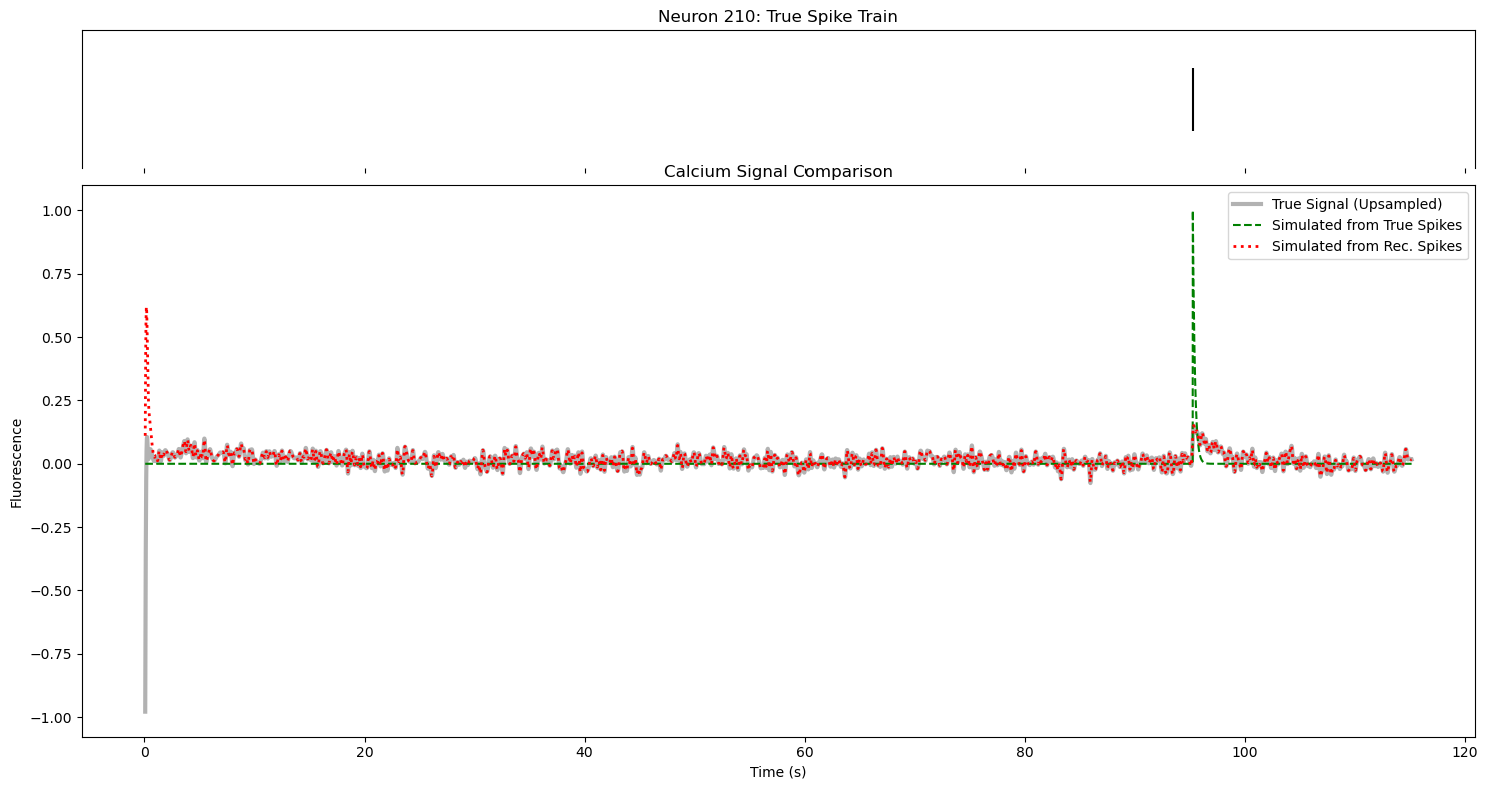

In [21]:
def plot_neuron_calcium_comparison(neuron_idx, neurons_list):
    n = neurons_list[neuron_idx]
    
    # Extract Data
    time = n['evenly_spaced_time']
    true_signal = n['upsampled_signal']
    true_spikes = n['original_neuron']['spikes']
    
    sim_true = n.get('sim_calcium_from_true')
    sim_rec = n.get('sim_calcium_from_rec')
    
    # Create Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True, 
                                   gridspec_kw={'height_ratios': [1, 4]})
    
    # --- Top Panel: Event Plot of True Spikes ---
    # We convert spike times to indices for eventplot if needed, or just plot on time axis
    ax1.eventplot(true_spikes, lineoffsets=0.5, linelengths=0.8, color='k')
    ax1.set_title(f'Neuron {neuron_idx}: True Spike Train')
    ax1.set_yticks([])
    ax1.spines['bottom'].set_visible(False) # Cosmetic: hide bottom spine to link plots
    
    # --- Bottom Panel: Calcium Signals Superimposed ---
    ax2.plot(time, true_signal, 'k-', alpha=0.3, lw=3, label='True Signal (Upsampled)')
    
    if sim_true is not None:
        ax2.plot(time, sim_true, 'g--', lw=1.5, label='Simulated from True Spikes')
        
    if sim_rec is not None:
        ax2.plot(time, sim_rec, 'r:', lw=2, label='Simulated from Rec. Spikes')
        
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Fluorescence')
    ax2.legend(loc='upper right')
    ax2.set_title('Calcium Signal Comparison')
    
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.05) # Bring plots closer
    plt.show()

# Example Usage:
plot_neuron_calcium_comparison(neuron_idx=210, neurons_list=neurons)

In [22]:
def plot_separate_calcium_comparisons(neuron_idx, neurons_list):
    n = neurons_list[neuron_idx]
    
    # Extract Data
    time = n['evenly_spaced_time']
    true_signal = n['upsampled_signal']
    true_spikes = n['original_neuron']['spikes']
    
    sim_true = n.get('sim_calcium_from_true')
    sim_rec = n.get('sim_calcium_from_rec')
    
    # --- PLOT 1: True Signal vs. Simulated from TRUE Spikes ---
    fig1, (ax1a, ax1b) = plt.subplots(2, 1, figsize=(15, 6), sharex=True, 
                                      gridspec_kw={'height_ratios': [1, 4]})
    
    # Event Plot
    ax1a.eventplot(true_spikes, lineoffsets=0.5, linelengths=0.8, color='k')
    ax1a.set_title(f'Neuron {neuron_idx}: True Spikes & Simulation from TRUE Spikes')
    ax1a.set_yticks([])
    ax1a.spines['bottom'].set_visible(False)
    
    # Signal Plot
    ax1b.plot(time, true_signal, 'k-', alpha=0.3, lw=3, label='True Signal')
    if sim_true is not None:
        ax1b.plot(time, sim_true, 'g--', lw=1.5, label='Simulated (True Spikes)')
    
    ax1b.set_ylabel('Fluorescence')
    ax1b.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    
    # --- PLOT 2: True Signal vs. Simulated from RECONSTRUCTED Spikes ---
    fig2, (ax2a, ax2b) = plt.subplots(2, 1, figsize=(15, 6), sharex=True, 
                                      gridspec_kw={'height_ratios': [1, 4]})
    
    # Event Plot (Same true spikes for reference)
    ax2a.eventplot(true_spikes, lineoffsets=0.5, linelengths=0.8, color='k')
    ax2a.set_title(f'Neuron {neuron_idx}: True Spikes & Simulation from RECONSTRUCTED Spikes')
    ax2a.set_yticks([])
    ax2a.spines['bottom'].set_visible(False)
    
    # Signal Plot
    ax2b.plot(time, true_signal, 'k-', alpha=0.3, lw=3, label='True Signal')
    if sim_rec is not None:
        ax2b.plot(time, sim_rec, 'r:', lw=2, label='Simulated (Rec. Spikes)')
        
    ax2b.set_xlabel('Time (s)')
    ax2b.set_ylabel('Fluorescence')
    ax2b.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

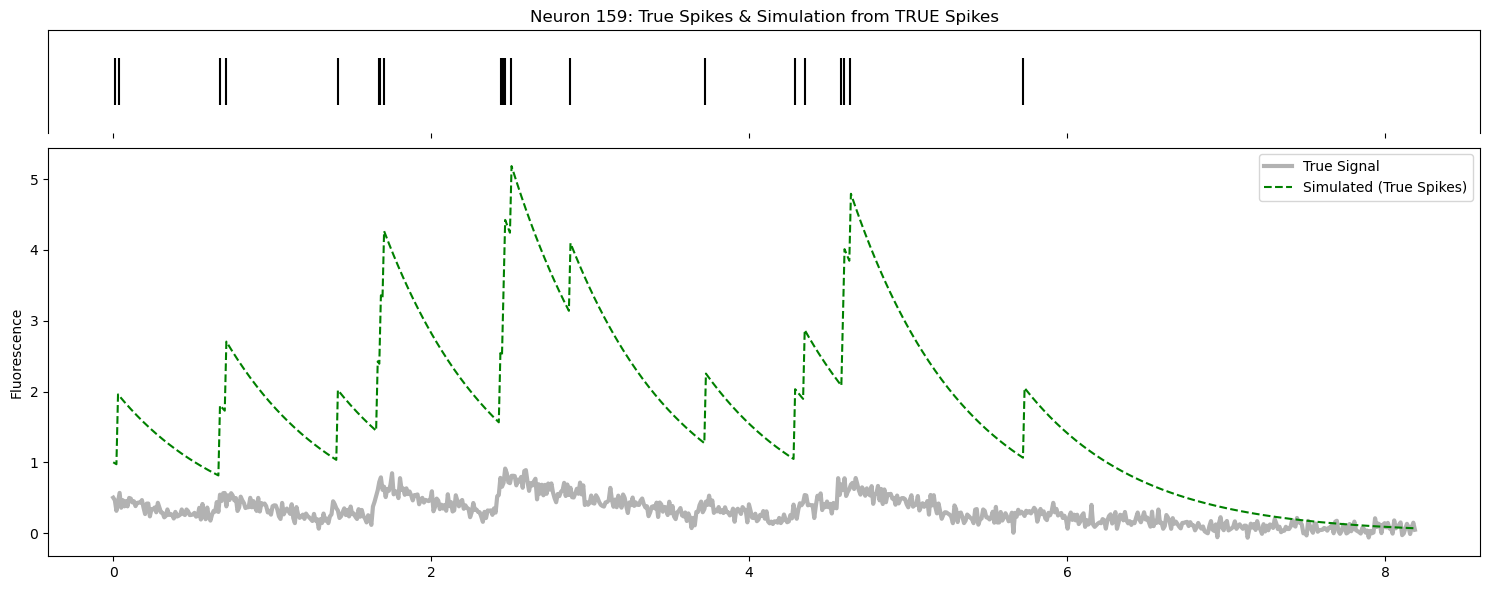

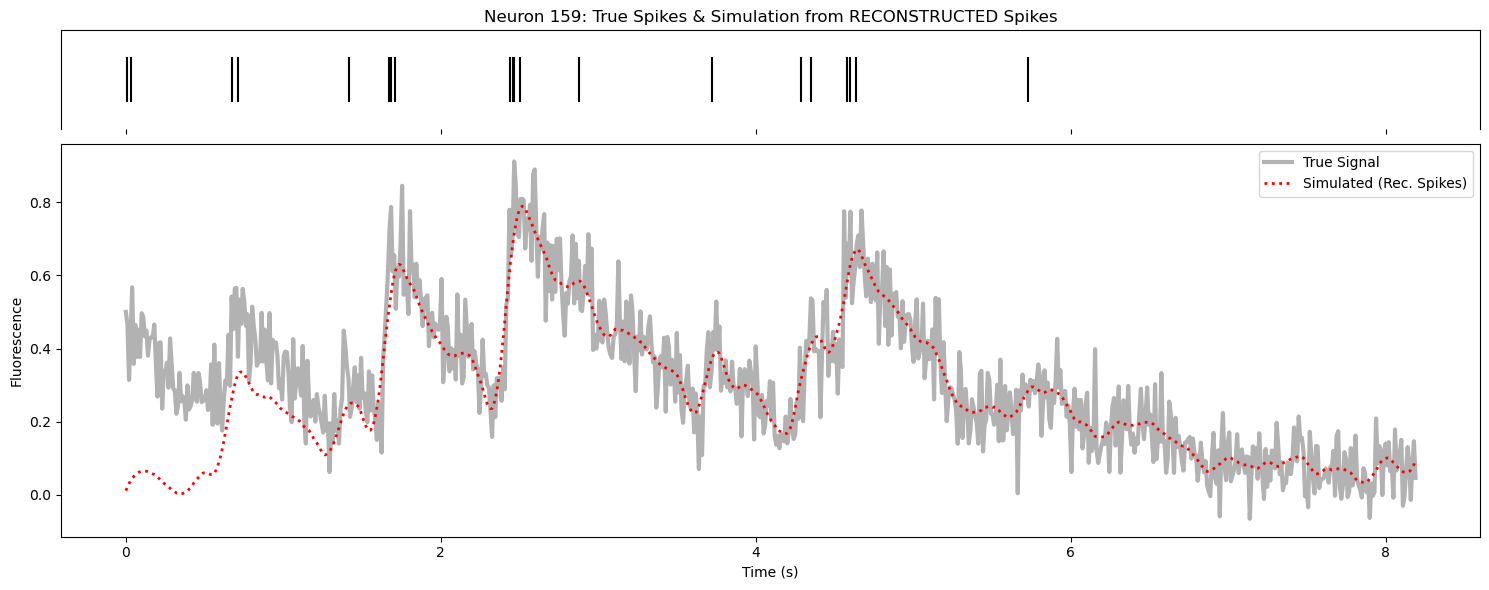

In [23]:
plot_separate_calcium_comparisons(neuron_idx=159, neurons_list=neurons)

After checking the similarity of the true and reconstructed dF/F signals, we measure their cross-correlations and lag.

<span style="color:red">**Important**</span>:
The following code can be improved. I don't need to re-calculated reconstruced calciums. It has been already added to neurons list in upper blocks.

In [24]:
for neuron in upsampled_results:
    # 1. Extract Data
    true_calcium = neuron['upsampled_signal']
    true_spikes_times = neuron['upsampled_spikes']
    time_grid = neuron['evenly_spaced_time']
    
    # Calculate sampling rate from time grid
    if len(time_grid) > 1:
        sampling_rate = 1.0 / (time_grid[1] - time_grid[0])
    else:
        sampling_rate = 100.0 # Default fallback
        
    # 2. Estimate Tau (Used for reconstruction)
    # Estimate Tau from true spikes if needed, or use existing logic
    # We need tau to perform the reconstruction from reconstructed spikes
    spikes_train = get_spikes_train(true_spikes_times, time_grid)
    
    try:
        tau_val, _ = estimate_tau(true_calcium, spikes_train)
    except:
        tau_val = np.nan
    
    if np.isnan(tau_val) or tau_val <= 0:
        tau_val = 1.0 # Default fallback
        
    tau_sec = tau_val
    tau_frames = tau_sec * sampling_rate
    
    # 3. Simulation: Calcium from RECONSTRUCTED Spikes ONLY
    # First, get the continuous reconstructed spike signal
    rec_spikes_continuous = reconstruct_spikes(true_calcium, tau=tau_frames)
    
    # Then simulate calcium from that continuous trace
    sim_calcium_from_rec = simulate_calcium_from_reconstructed_spikes(
        rec_spikes_continuous, tau_frames, noise_std=0.0
    )
    
    # 4. Calculate Correlation against True Calcium
    # ONLY Cross-Correlation (Max & Lag) for Rec Spikes Reconstruction
    xc_rec, lag_rec = calculate_cross_corr_max(true_calcium, sim_calcium_from_rec)
    
    # 5. Store Results
    neuron['tau_estimated'] = tau_sec
    
    # Rec Spikes Metrics
    neuron['xcorr_rec_spikes_max'] = xc_rec
    neuron['xcorr_rec_spikes_lag'] = lag_rec
    
    # Store trace if desired
    neuron['sim_calcium_from_rec'] = sim_calcium_from_rec
print(f"Computed correlations for {len(upsampled_results)} neurons.")

KeyboardInterrupt: 

- Top: The Analysis checks how well the cumulative binned reconstructed spikes and true spikes train are similar.
- Button: Cumulative summation of reconstructed spikes vs. true spikes train. 

<span style="color:red">**Important**</span>:
Binary spikes train are series of events that we consider 1 at the time of events. but we don't know exact rise of the signal at the time of events. So, in order to make reconstructed spikes and true spikes train comparable after calculating the slope of the cumsum, we calibrate the reconstructed spikes by deviding it by the slope. Again, we fit a line on the cumsum of calibrated vs. true passing the origin. $R^2$ shows the  goodness of the fit. Then we add all these measurments data to the neurons list.


--- Calibration Dashboard for Neuron 70 ---


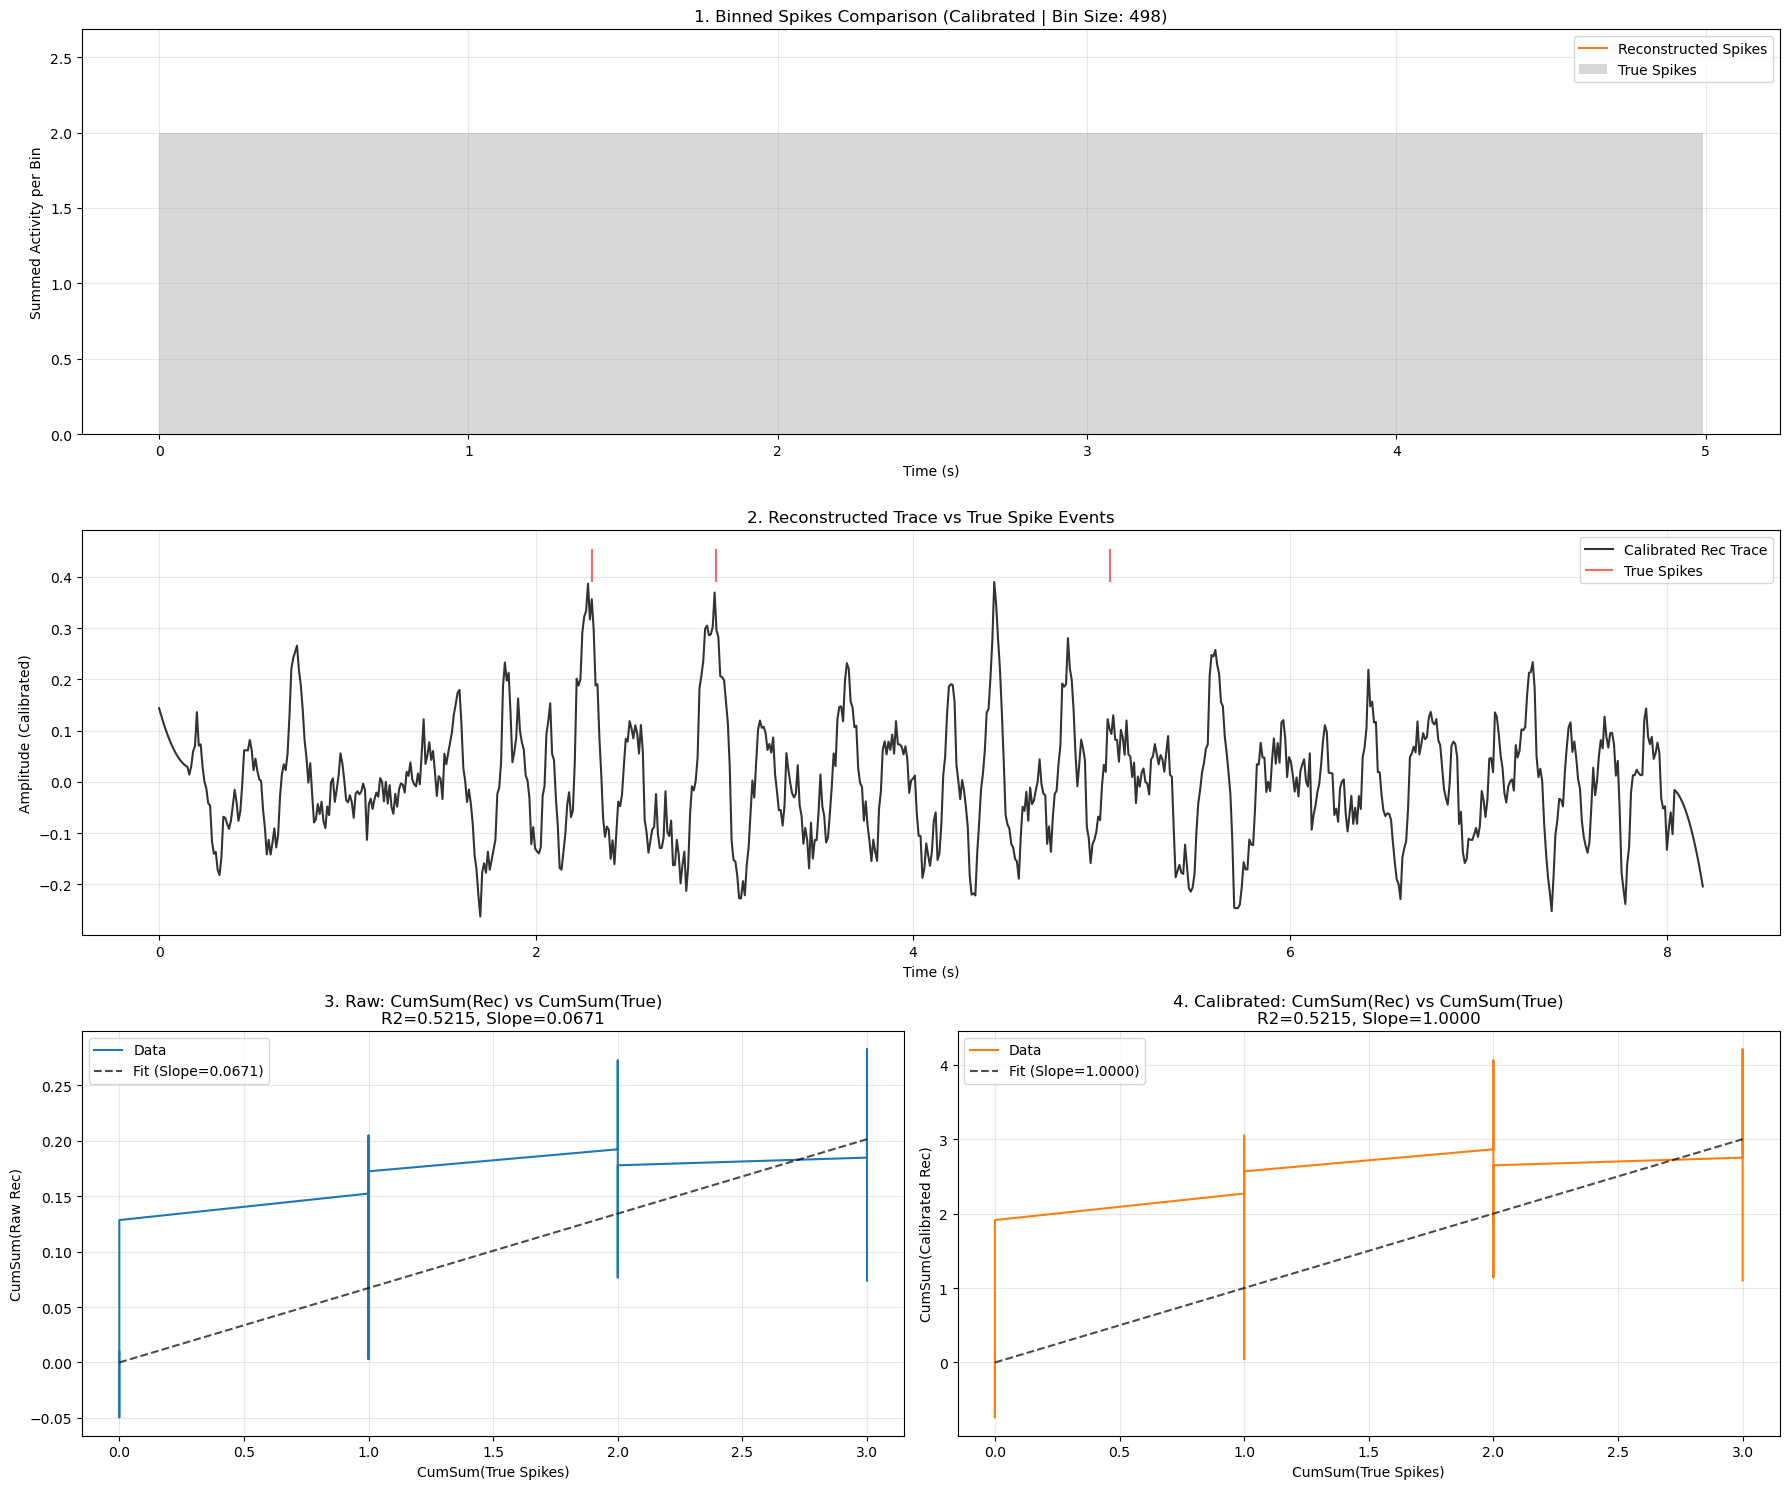

In [26]:
# --- User Configuration ---
neuron_idx = 70
bin_size_sec = 5
# --------------------------

n = neurons[neuron_idx]

# 1. Prepare Data
time_vector = n['evenly_spaced_time']
if len(time_vector) > 1:
    dt = time_vector[1] - time_vector[0]
    fs = 1.0 / dt
else:
    fs = 100.0

reconstructed_spikes = n['reconstructed_spikes']
true_spike_times = n['original_neuron']['spikes']
true_spikes_train = get_spikes_train(true_spike_times, time_vector)

# 2. Analyze
# This now uses LinearRegression(fit_intercept=False) and r2_score internally
calibration_results = analyze_cumsum_calibration(true_spikes_train, reconstructed_spikes)

# 3. Plot Dashboard
bin_size_samples = int(bin_size_sec * fs)

print(f"--- Calibration Dashboard for Neuron {neuron_idx} ---")
plot_calibration_dashboard(
    true_spikes_train, 
    reconstructed_spikes, 
    calibration_results, 
    bin_size=bin_size_samples, 
    sampling_rate=fs
)

In [27]:
# Loop through all neurons
for i, n in enumerate(neurons):
    # 1. Prepare Data
    time_vector = n['evenly_spaced_time']
    reconstructed_spikes = n['reconstructed_spikes']
    true_spike_times = n['original_neuron']['spikes']
    
    # Generate binary spike train required for analysis
    true_spikes_train = get_spikes_train(true_spike_times, time_vector)
    
    # 2. Calculate Calibration Metrics
    # This returns slope/r2 for both raw and calibrated, we want RAW.
    calibration_results = analyze_cumsum_calibration(true_spikes_train, reconstructed_spikes)
    
    # 3. Add to neuron dictionary
    n['cumsum_r2_raw'] = calibration_results['r2_raw']
    n['cumsum_slope_raw'] = calibration_results['slope_raw']
    n['calibrated_spikes'] = calibration_results['calibrated_trace'] # Optionally save the trace too

    # Progress print
    if i % 10 == 0:
        print(f"Processed neuron {i}: R2={n['cumsum_r2_raw']:.3f}, Slope={n['cumsum_slope_raw']:.3f}")

print("Added 'cumsum_r2_raw' and 'cumsum_slope_raw' to all neurons.")

Processed neuron 0: R2=0.883, Slope=0.034
Processed neuron 10: R2=0.993, Slope=0.063
Processed neuron 20: R2=0.485, Slope=0.033
Processed neuron 30: R2=0.981, Slope=0.025
Processed neuron 40: R2=0.929, Slope=0.043
Processed neuron 50: R2=0.708, Slope=0.177
Processed neuron 60: R2=0.660, Slope=0.212
Processed neuron 70: R2=0.521, Slope=0.067
Processed neuron 80: R2=0.776, Slope=0.486
Processed neuron 90: R2=-0.139, Slope=0.002
Processed neuron 100: R2=1.000, Slope=-0.000
Processed neuron 110: R2=0.997, Slope=0.212
Processed neuron 120: R2=0.969, Slope=0.271
Processed neuron 130: R2=0.795, Slope=0.156
Processed neuron 140: R2=0.987, Slope=0.230
Processed neuron 150: R2=0.937, Slope=0.272
Processed neuron 160: R2=0.990, Slope=0.159
Processed neuron 170: R2=0.954, Slope=0.207
Processed neuron 180: R2=0.995, Slope=0.179
Processed neuron 190: R2=0.774, Slope=2.250
Processed neuron 200: R2=-0.229, Slope=1.376
Processed neuron 210: R2=-4.484, Slope=9.385
Processed neuron 220: R2=0.947, Slope=0

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, welch

def plot_neuron_spectral_analysis(neuron_index, neurons, sampling_rate=100, xlog=False, ylog=False):

    if neuron_index < 0 or neuron_index >= len(neurons):
        print(f"Index {neuron_index} out of bounds.")
        return

    # Extract data using specified keys
    data = neurons[neuron_index]
    
    # Define signals to plot with display names and dictionary keys
    signals_info = [
        ("True Calcium", 'upsampled_signal'),
        ("True Spike", 'spikes_train'),
        ("Reconstructed Spike", 'reconstructed_spikes'),
        ("Reconstructed Calcium", 'sim_calcium_from_rec')
    ]
    
    fig, axes = plt.subplots(4, 2, figsize=(12, 12), constrained_layout=True)
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
    
    for i, (label, key) in enumerate(signals_info):
        sig = data.get(key)
        
        if sig is None:
            print(f"Warning: Key '{key}' not found for neuron {neuron_index}")
            continue
            
        sig = np.array(sig)
        
        # --- Autocorrelation ---
        ax_corr = axes[i, 0]
        
        # Center and normalize for autocorrelation
        sig_centered = sig - np.mean(sig)
        if np.std(sig_centered) != 0:
            sig_centered /= np.std(sig_centered)
            
        corr = correlate(sig_centered, sig_centered, mode='full') / len(sig)
        lags = np.arange(-len(sig)+1, len(sig)) / sampling_rate
        
        # Plot +/- 2 seconds zoom centered at 0 if linear, or full positive if log
        mask = (lags >= -2) & (lags <= 2)
        
        ax_corr.plot(lags[mask], corr[mask], color=colors[i])
        
        if xlog:
            ax_corr.set_xscale('log')
        if ylog:
            ax_corr.set_yscale('log')
            
        ax_corr.set_title(f"{label} - Autocorrelation")
        ax_corr.set_xlabel("Lag (s)")
        ax_corr.set_ylabel("Correlation")
        ax_corr.grid(True, alpha=0.3, which='both')
        
        # --- PSD ---
        ax_psd = axes[i, 1]
        freqs, psd = welch(sig, fs=sampling_rate, nperseg=min(len(sig), 1024))
        
        ax_psd.plot(freqs, psd, color=colors[i])
        
        if xlog:
            ax_psd.set_xscale('log')
        if ylog:
            ax_psd.set_yscale('log')
            
        ax_psd.set_title(f"{label} - PSD")
        ax_psd.set_xlabel("Frequency (Hz)")
        ax_psd.set_ylabel("Power Density")
        ax_psd.grid(True, alpha=0.3, which='both')
        
    plt.suptitle(f"Neuron {neuron_index} Spectral Analysis", fontsize=16)
    plt.show()

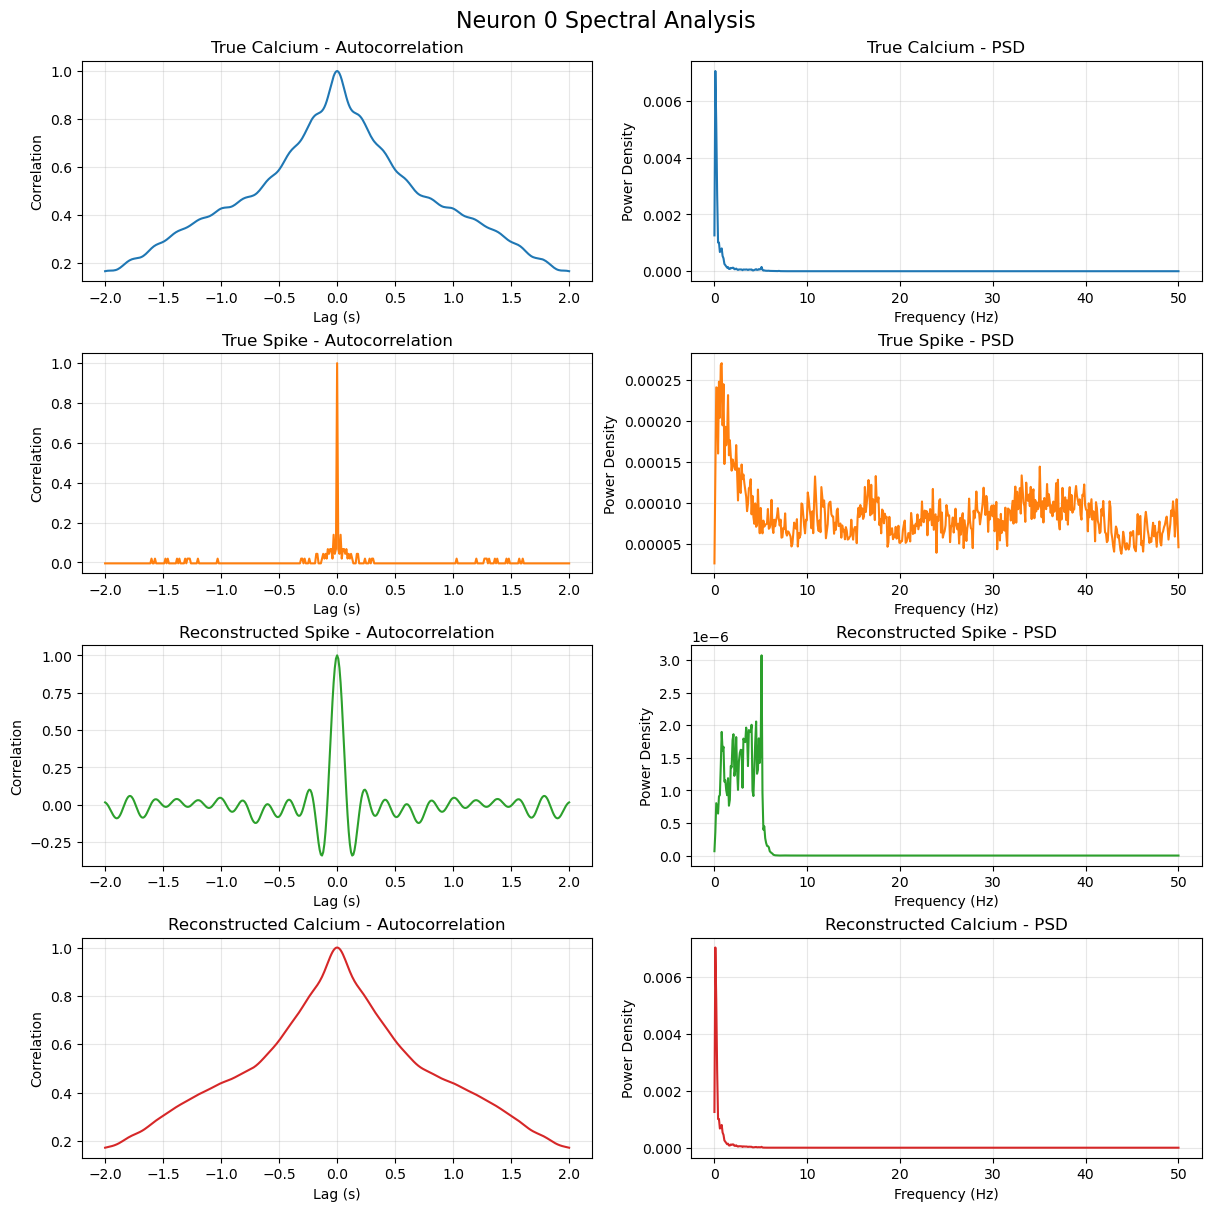

In [29]:
plot_neuron_spectral_analysis(0, neurons, sampling_rate=100, xlog=False, ylog=False)

In [36]:
neurons[0]['spikes_train']

array([0., 0., 0., ..., 0., 0., 0.])

**Dataframe of the active neurons**

In [18]:
# 1. Extract data
data = []
# Assuming the list is named 'upsampled_results'
for i, n in enumerate(upsampled_results):
    # Handle Database Name 
    db_name = n.get('dataset_name')
    if not db_name and 'original_neuron' in n:
        db_name = n['original_neuron'].get('dataset_name')
    if not db_name:
        db_name = 'Unknown'
        
    # Existing Metrics
    tau_val = n.get('tau', n.get('tau_estimated', np.nan))
    slope_val = n.get('cumsum_slope_raw', np.nan)
    r2_val = n.get('cumsum_r2_raw', np.nan)
    
    # --- NEW MEASUREMENTS ---
    # Only Cross-Corr and Lag for Rec Spikes Reconstruction
    xcorr_rec = n.get('xcorr_rec_spikes_max', np.nan)
    lag_rec = n.get('xcorr_rec_spikes_lag', np.nan)
    
    data.append({
        'Neuron_ID': i,
        'Database': db_name,
        'Tau': tau_val,
        'Cumsum_Slope': slope_val,
        'R^2': r2_val,
        # New Columns
        'XCorr_Rec': xcorr_rec,
        'Lag_Rec': lag_rec
    })
df_results = pd.DataFrame(data)
# Optional: Reorder columns
cols = [
    'Neuron_ID', 'Database', 'Tau', 'Cumsum_Slope', 'R^2',
    'XCorr_Rec', 'Lag_Rec'
]
df_results = df_results[cols]

In [19]:
# 1. (Keep your data extraction code as is)

# 2. Set the display limit for the dataframe itself
pd.set_option('display.max_rows', 50) 

# 3. Display with a scrollable container
print(f"Total Neurons: {len(df_results)}")

# This creates a scrollable window 400px high
display(df_results.style.set_table_attributes('style="display:inline-block; max-height:1000px; overflow-y:auto;"'))

Total Neurons: 502


,Neuron_ID,Database,Tau,Cumsum_Slope,R^2,XCorr_Rec,Lag_Rec
0,0,DS01-OGB1-m-V1,205.300158,0.039456,0.988654,0.986516,0.000000
1,1,DS01-OGB1-m-V1,183.718850,0.039464,0.975320,0.978636,0.000000
2,2,DS01-OGB1-m-V1,1498.215544,0.001165,0.933665,0.993052,0.000000
3,3,DS01-OGB1-m-V1,179.348463,0.028632,0.998379,0.939979,0.000000
4,4,DS01-OGB1-m-V1,107.748766,0.049193,0.992792,0.992615,0.000000
5,5,DS01-OGB1-m-V1,143.159922,0.021846,0.986112,0.735106,1.000000
6,6,DS01-OGB1-m-V1,225.373844,0.033076,0.992227,0.991152,0.000000
7,7,DS01-OGB1-m-V1,183.036849,0.035953,0.263639,0.991382,0.000000
8,8,DS01-OGB1-m-V1,490.886998,0.021288,0.990151,0.979931,0.000000
9,9,DS01-OGB1-m-V1,398.162372,0.052004,0.978537,0.988894,0.000000


<Axes: >

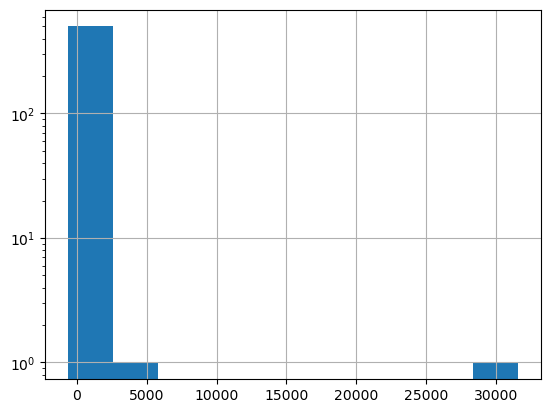

In [24]:
df_results['Lag_Rec'].hist(log=True)

<Axes: >

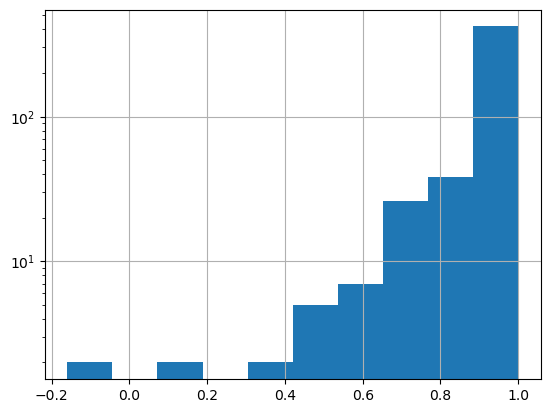

In [25]:
df_results['Corr_Rec'].hist(log=True)

<Axes: >

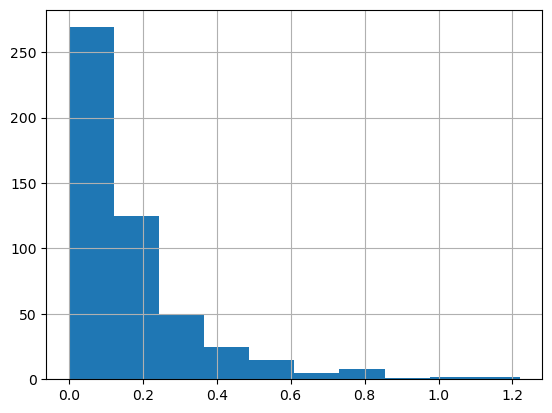

In [29]:
df_results['Cumsum_Slope'].hist()

<Axes: >

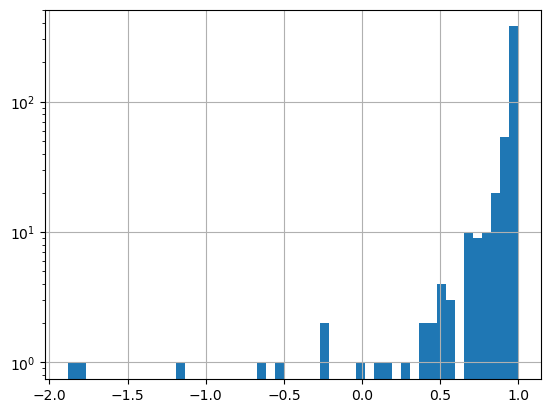

In [40]:
df_results['R^2'].hist(log=True, bins=50)

In [21]:
df_results.to_csv('tau_results.txt', sep=',', index=False)

this is a part just for cheking the performance of my own written simulation of forward calcium model and compare it with the scipy lfilter function. During analysis I was worried about it and wrote a function to check it.

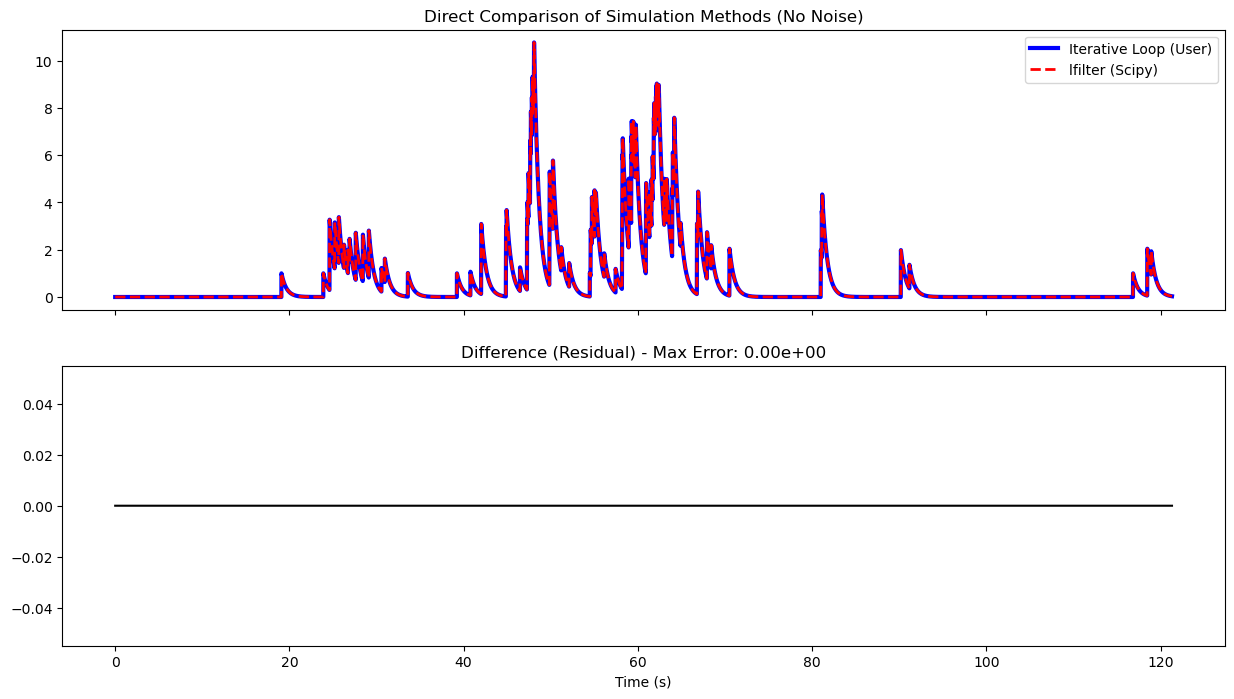

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from functions.method import simulate_calcium_iterative_true_spikes, simulate_calcium_from_true_spikes

# 1. Select Data
n = neurons[410]
true_spikes = n['original_neuron']['spikes']
time_grid = n['evenly_spaced_time']
tau = n['tau']
fs = 100

# 2. Run Both Simulations (Zero Noise for fair comparison of the core logic)
# A: Iterative (Your Logic)
sim_iter = simulate_calcium_iterative_true_spikes(
    true_spikes, time_grid, tau, fs, noise_intra=0.0, noise_rec=0.0
)

# B: Filter-based (Scipy lfilter)
sim_filter = simulate_calcium_from_true_spikes(
    true_spikes, time_grid, tau, fs, noise_std=0.0
)

# 3. Plot Difference
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax1.plot(time_grid, sim_iter, 'b', lw=3, label='Iterative Loop (User)')
ax1.plot(time_grid, sim_filter, 'r--', lw=2, label='lfilter (Scipy)')
ax1.set_title('Direct Comparison of Simulation Methods (No Noise)')
ax1.legend()

# Show residual
residual = sim_iter - sim_filter
ax2.plot(time_grid, residual, 'k')
ax2.set_title(f'Difference (Residual) - Max Error: {np.max(np.abs(residual)):.2e}')
ax2.set_xlabel('Time (s)')

plt.show()